In [16]:
import os

import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')

In [2]:
train_path = os.path.join('data', 'FIFA_train.csv')
test_path = os.path.join('data', 'FIFA_test.csv')
submission_path = os.path.join('data', 'submission.csv')

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
submission = pd.read_csv(submission_path)

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8932 entries, 0 to 8931
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                8932 non-null   int64  
 1   name              8932 non-null   object 
 2   age               8932 non-null   int64  
 3   continent         8932 non-null   object 
 4   contract_until    8932 non-null   object 
 5   position          8932 non-null   object 
 6   prefer_foot       8932 non-null   object 
 7   reputation        8932 non-null   float64
 8   stat_overall      8932 non-null   int64  
 9   stat_potential    8932 non-null   int64  
 10  stat_skill_moves  8932 non-null   float64
 11  value             8932 non-null   float64
dtypes: float64(3), int64(4), object(5)
memory usage: 837.5+ KB


In [6]:
# 메모리 사용을 줄이는 법!
train[['age', 'stat_overall', 'stat_potentail']] = train[['age', 'stat_overall', 'stat_potential']].astype(np.int32)

In [7]:
train.info() # 아웃오브메모리 날 때 쓰면 좋다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8932 entries, 0 to 8931
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                8932 non-null   int64  
 1   name              8932 non-null   object 
 2   age               8932 non-null   int32  
 3   continent         8932 non-null   object 
 4   contract_until    8932 non-null   object 
 5   position          8932 non-null   object 
 6   prefer_foot       8932 non-null   object 
 7   reputation        8932 non-null   float64
 8   stat_overall      8932 non-null   int32  
 9   stat_potential    8932 non-null   int64  
 10  stat_skill_moves  8932 non-null   float64
 11  value             8932 non-null   float64
 12  stat_potentail    8932 non-null   int32  
dtypes: float64(3), int32(3), int64(2), object(5)
memory usage: 802.6+ KB


In [9]:
# 기술통계량 확인
train.describe().T # 숫자형 데이터만 나온다.

,count,mean,std,min,25%,50%,75%,max
id,8932.0,7.966776e+03,4.844429e+03,0.0,3751.75,7696.5,12082.25,16948.0
age,8932.0,2.520914e+01,4.635515e+00,16.0,21.00,25.0,28.00,40.0
reputation,8932.0,1.130878e+00,4.237919e-01,1.0,1.00,1.0,1.00,5.0
stat_overall,8932.0,6.709113e+01,6.854910e+00,47.0,63.00,67.0,72.00,94.0
stat_potential,8932.0,7.199720e+01,5.988147e+00,48.0,68.00,72.0,76.00,94.0
stat_skill_moves,8932.0,2.401702e+00,7.760476e-01,1.0,2.00,2.0,3.00,5.0
value,8932.0,2.778673e+06,5.840982e+06,10000.0,375000.00,825000.0,2600000.00,110500000.0
stat_potentail,8932.0,7.199720e+01,5.988147e+00,48.0,68.00,72.0,76.00,94.0


In [12]:
train[['continent', 'contract_until', 'prefer_foot', 'position', 'name']].describe().T
# 범주형만 넣고보면 달라진다.

,count,unique,top,freq
continent,8932,5,europe,5322
contract_until,8932,17,2019,2366
prefer_foot,8932,2,right,6837
position,8932,4,MF,3428
name,8932,8932,M. Håkansson,1


In [13]:
# 데이터 정렬해서 보기
train.sort_values(by='value', ascending=False)[:50]

,id,name,age,continent,contract_until,position,prefer_foot,reputation,stat_overall,stat_potential,stat_skill_moves,value,stat_potentail
0,0,L. Messi,31,south america,2021,ST,left,5.0,94,94,4.0,110500000.0,94
2,7,L. Suárez,31,south america,2021,ST,right,5.0,91,91,3.0,80000000.0,91
17,30,Isco,26,europe,2022,ST,right,3.0,88,91,4.0,73500000.0,91
1,3,De Gea,27,europe,2020,GK,right,4.0,91,93,1.0,72000000.0,93
14,26,M. Salah,26,africa,2023,MF,left,3.0,88,89,4.0,69500000.0,89
18,32,Coutinho,26,south america,2023,ST,right,3.0,88,89,5.0,69500000.0,89
4,9,J. Oblak,25,europe,2021,GK,right,3.0,90,93,1.0,68000000.0,93
26,45,P. Pogba,25,europe,2021,MF,right,4.0,87,91,5.0,64000000.0,91
7,14,N. Kanté,27,europe,2023,MF,right,3.0,89,90,2.0,63000000.0,90
27,47,R. Lukaku,25,europe,2022,ST,left,3.0,87,89,3.0,62500000.0,89


+ 데이터를 이렇게 저렇게 굴려서 인사이트를 찾아내는 것!
+ 피처나 새로운 아이디어를 추가할 수 있음.
+ 도메인 지식이 중요하다.

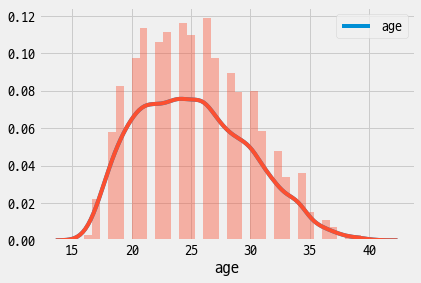

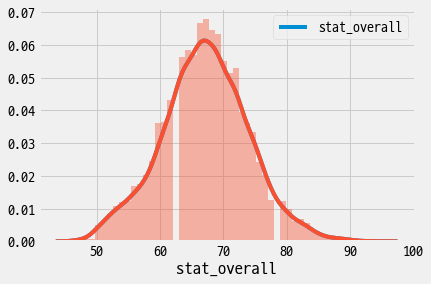

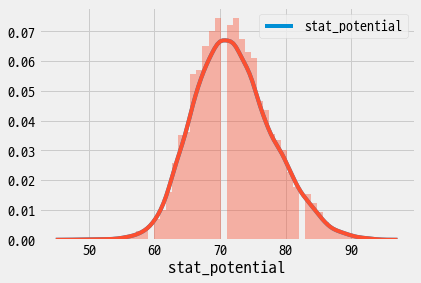

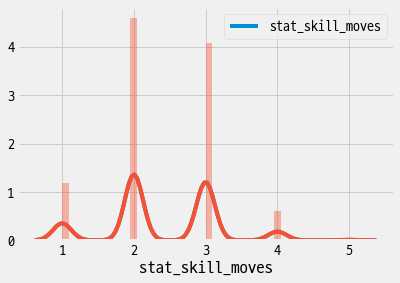

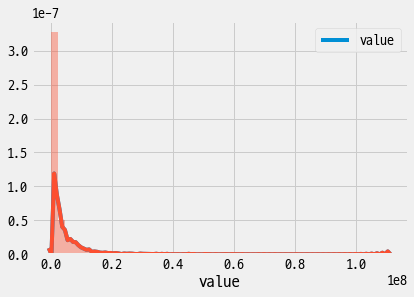

In [20]:
# distribution
cols = ['age', 'stat_overall', 'stat_potential', 'stat_skill_moves', 'value']
for col in cols:
#     sns.kedplot(data=train, x=col)
    sns.kdeplot(train[col])
    sns.distplot(train[col])
    plt.show()

In [18]:
train.head(1)

,id,name,age,continent,contract_until,position,prefer_foot,reputation,stat_overall,stat_potential,stat_skill_moves,value,stat_potentail
0,0,L. Messi,31,south america,2021,ST,left,5.0,94,94,4.0,110500000.0,94


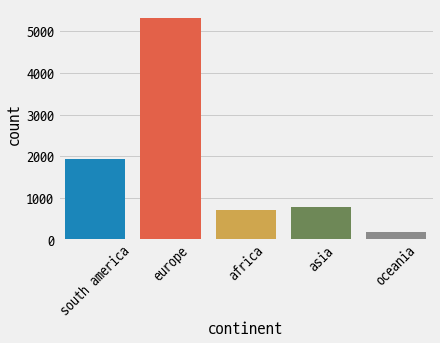

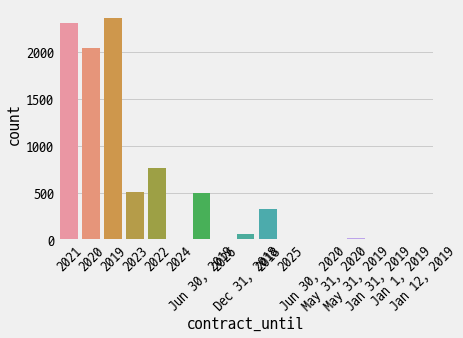

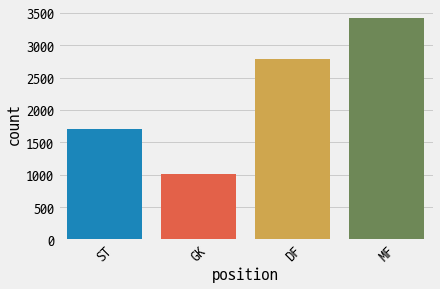

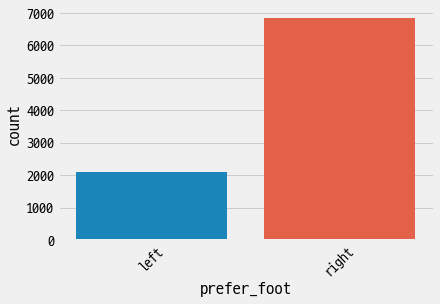

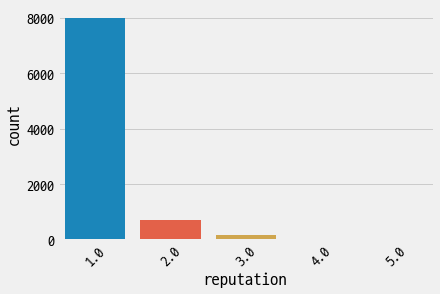

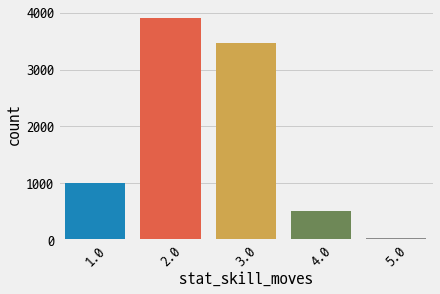

In [21]:
# 범주형 데이터
# countplot
cols = ['continent', 'contract_until', 'position', 'prefer_foot', 'reputation', 'stat_skill_moves']
for col in cols:
    sns.countplot(train[col])
    plt.xticks(rotation=45)
    plt.show()

In [22]:
# groupby 사용하기
train.groupby('reputation')['value'].mean() # 숫자가 크게 나옴

reputation
1.0    1.690092e+06
2.0    8.639221e+06
3.0    2.201483e+07
4.0    3.342903e+07
5.0    6.062500e+07
Name: value, dtype: float64

In [23]:
# 옵션이 있다!
pd.set_option('precision', 100) # 이렇게 하면 숫자가 다 보임!
train.groupby('reputation')['value'].mean()

reputation
1.0     1690091.71449962561018764972686767578125
2.0     8639220.96317280456423759460449218750000
3.0    22014830.50847457721829414367675781250000
4.0    33429032.25806451588869094848632812500000
5.0    60625000.00000000000000000000000000000000
Name: value, dtype: float64

In [25]:
train.groupby(['reputation', 'stat_skill_moves'])['value'].mean()

reputation  stat_skill_moves
1.0         1.0                   1041406.250000000000000000000000000000000
            2.0                    982351.270957274246029555797576904296875
            3.0                   2252813.620071684475988149642944335937500
            4.0                   6376045.016077170148491859436035156250000
            5.0                   6050000.000000000000000000000000000000000
2.0         1.0                   7947000.000000000000000000000000000000000
            2.0                   6837245.508982036262750625610351562500000
            3.0                   7242123.493975903838872909545898437500000
            4.0                  13671126.760563381016254425048828125000000
            5.0                  17470000.000000000000000000000000000000000
3.0         1.0                  20947368.421052630990743637084960937500000
            2.0                  22000000.000000000000000000000000000000000
            3.0                  17406967.21311475336551666

In [40]:
train.groupby(['reputation', 'stat_skill_moves'])['value'].mean().index

MultiIndex([(1.0, 1.0),
            (1.0, 2.0),
            (1.0, 3.0),
            (1.0, 4.0),
            (1.0, 5.0),
            (2.0, 1.0),
            (2.0, 2.0),
            (2.0, 3.0),
            (2.0, 4.0),
            (2.0, 5.0),
            (3.0, 1.0),
            (3.0, 2.0),
            (3.0, 3.0),
            (3.0, 4.0),
            (3.0, 5.0),
            (4.0, 1.0),
            (4.0, 2.0),
            (4.0, 3.0),
            (4.0, 4.0),
            (4.0, 5.0),
            (5.0, 1.0),
            (5.0, 3.0),
            (5.0, 4.0),
            (5.0, 5.0)],
           names=['reputation', 'stat_skill_moves'])

In [41]:
train.groupby(['reputation', 'stat_skill_moves'])['value'].mean()[1.0]

stat_skill_moves
1.0    1041406.250000000000000000000000000000000
2.0     982351.270957274246029555797576904296875
3.0    2252813.620071684475988149642944335937500
4.0    6376045.016077170148491859436035156250000
5.0    6050000.000000000000000000000000000000000
Name: value, dtype: float64

In [42]:
train.groupby(['reputation', 'stat_skill_moves'])['value'].mean().reset_index()

,reputation,stat_skill_moves,value
0,1.0,1.0,1041406.250000000000000000000000000000000
1,1.0,2.0,982351.270957274246029555797576904296875
2,1.0,3.0,2252813.620071684475988149642944335937500
3,1.0,4.0,6376045.016077170148491859436035156250000
4,1.0,5.0,6050000.000000000000000000000000000000000
5,2.0,1.0,7947000.000000000000000000000000000000000
6,2.0,2.0,6837245.508982036262750625610351562500000
7,2.0,3.0,7242123.493975903838872909545898437500000
8,2.0,4.0,13671126.760563381016254425048828125000000
9,2.0,5.0,17470000.000000000000000000000000000000000


+ groupby를 잘 사용하면 데이터를 다양한 관점에서 살펴볼 수 있다.

# 피처 엔지니어링

+ 좋아질 수도 나빠질 수도 있음

In [26]:
train['contract_until'] = train['contract_until'].map(lambda x : x[-4:])

In [27]:
train['contract_until'].unique()

array(['2021', '2020', '2019', '2023', '2022', '2024', '2026', '2018',
       '2025'], dtype=object)

In [28]:
# 데이터 타입 변경
train['contract_until'] = train['contract_until'].astype(np.int32)

In [29]:
train['contract_until'] = train['contract_until'] - 2018

In [30]:
train['contract_until']

0       3
1       2
2       3
3       2
4       3
       ..
8927    1
8928    2
8929    3
8930    3
8931    2
Name: contract_until, Length: 8932, dtype: int32

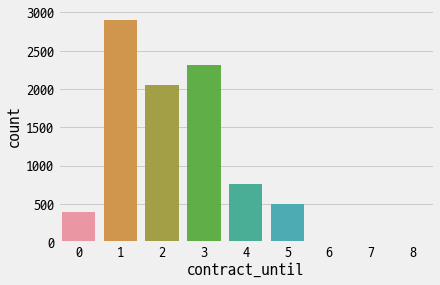

In [31]:
sns.countplot(train['contract_until'])
plt.show()

In [32]:
train.head()

,id,name,age,continent,contract_until,position,prefer_foot,reputation,stat_overall,stat_potential,stat_skill_moves,value,stat_potentail
0,0,L. Messi,31,south america,3,ST,left,5.0,94,94,4.0,110500000.0,94
1,3,De Gea,27,europe,2,GK,right,4.0,91,93,1.0,72000000.0,93
2,7,L. Suárez,31,south america,3,ST,right,5.0,91,91,3.0,80000000.0,91
3,8,Sergio Ramos,32,europe,2,DF,right,4.0,91,91,3.0,51000000.0,91
4,9,J. Oblak,25,europe,3,GK,right,3.0,90,93,1.0,68000000.0,93


In [33]:
# 새로운 컬럼 만들기
train['stat_potent'] = train['stat_potential'] - train['stat_overall']

In [34]:
train.head()

,id,name,age,continent,contract_until,position,prefer_foot,reputation,stat_overall,stat_potential,stat_skill_moves,value,stat_potentail,stat_potent
0,0,L. Messi,31,south america,3,ST,left,5.0,94,94,4.0,110500000.0,94,0
1,3,De Gea,27,europe,2,GK,right,4.0,91,93,1.0,72000000.0,93,2
2,7,L. Suárez,31,south america,3,ST,right,5.0,91,91,3.0,80000000.0,91,0
3,8,Sergio Ramos,32,europe,2,DF,right,4.0,91,91,3.0,51000000.0,91,0
4,9,J. Oblak,25,europe,3,GK,right,3.0,90,93,1.0,68000000.0,93,3


In [35]:
# 축구선수 평균 은퇴 나이 35세
train['retire_age'] = 35 - train['age']

In [37]:
train.head()

,id,name,age,continent,contract_until,position,prefer_foot,reputation,stat_overall,stat_potential,stat_skill_moves,value,stat_potentail,stat_potent,retire_age
0,0,L. Messi,31,south america,3,ST,left,5.0,94,94,4.0,110500000.0,94,0,4
1,3,De Gea,27,europe,2,GK,right,4.0,91,93,1.0,72000000.0,93,2,8
2,7,L. Suárez,31,south america,3,ST,right,5.0,91,91,3.0,80000000.0,91,0,4
3,8,Sergio Ramos,32,europe,2,DF,right,4.0,91,91,3.0,51000000.0,91,0,3
4,9,J. Oblak,25,europe,3,GK,right,3.0,90,93,1.0,68000000.0,93,3,10


In [38]:
train['retire_age'].min()

-5